# Loan Default Prediction - Exploratory Data Analysis (EDA)

**Goal:** understand the cleaned Credit Risk data before training models - how many loans default,
which borrower and loan features are linked to default, what is missing or unusual, and whether any column
looks "too good to be true" (leakage).

**Data:** Kaggle "Credit Risk Dataset" (`data/raw/credit_risk_dataset.csv`), cleaned by `src/clean_data.py`
into `data/processed/credit_clean.parquet`. One row = one loan applicant. `loan_status = 1` means the loan defaulted.
The data has **no date column**, so there is no "default rate over time" chart (drift is simulated later, Step 9).

Every chart is saved to `reports/figures/` so it can go straight into the project report.

In [1]:
import json
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap

# Works whether the notebook is opened from the project folder or from notebooks/
PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT / "src"))
from load_data import CATEGORICAL_FEATURES, NUMERIC_FEATURES, get_splits
from leakage_check import single_feature_auc

DATA = PROJECT / "data" / "processed"
RAW = PROJECT / "data" / "raw" / "credit_risk_dataset.csv"
FIG = PROJECT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# Chart style: one blue for single-series charts, blue vs orange for repaid vs defaulted,
# quiet grey axes and grid so the data stands out.
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "axes.edgecolor": AXIS, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "legend.frameon": False,
})
pct = mtick.PercentFormatter(1.0, decimals=0)

def save(fig, name):
    fig.savefig(FIG / f"{name}.png")
    plt.show()

def default_rate_bars(ax, rates, overall, horizontal=False, labels=None, note=True):
    # Bar chart of default rate per group with the overall average as a dashed reference line.
    names = [str(x) for x in (labels if labels is not None else rates.index)]
    if horizontal:
        ax.barh(names, rates.values, color=BLUE, height=0.6)
        ax.axvline(overall, color=MUTED, ls="--", lw=1)
        ax.xaxis.set_major_formatter(pct); ax.grid(axis="y", visible=False)
        for i, v in enumerate(rates.values):
            ax.text(v + 0.006, i, f"{v:.1%}", va="center", color=INK2, fontsize=9)
    else:
        ax.bar(names, rates.values, color=BLUE, width=0.6)
        ax.axhline(overall, color=MUTED, ls="--", lw=1)
        ax.yaxis.set_major_formatter(pct); ax.grid(axis="x", visible=False)
        for i, v in enumerate(rates.values):
            ax.text(i, v + 0.012, f"{v:.1%}", ha="center", color=INK2, fontsize=9)
    if note:
        ax.text(1.0, 1.01, f"dashed line = overall {overall:.1%}", transform=ax.transAxes,
                ha="right", va="bottom", color=MUTED, fontsize=8.5)

## 1. Data overview

In [2]:
raw = pd.read_csv(RAW)
df = pd.read_parquet(DATA / "credit_clean.parquet")
report = json.loads((DATA / "cleaning_report.json").read_text())
y = df["loan_status"]
OVERALL = y.mean()
print(f"Raw file:   {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"Cleaned:    {df.shape[0]:,} rows x {df.shape[1]} columns (added loan_id, loan_grade_num)")
print("Removed by cleaning:", report["rows_removed"])
print(f"Model features: {len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical")
df.head()

Raw file:   32,581 rows x 12 columns
Cleaned:    32,409 rows x 14 columns (added loan_id, loan_grade_num)
Removed by cleaning: {'exact_duplicates': 165, 'age_above_100': 5, 'emp_length_above_age_minus_14': 2}
Model features: 9 numeric + 2 categorical


,loan_id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_grade_num,loan_status
0,2,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0.10,0,2,2,0
1,3,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,0.57,0,3,3,1
2,4,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,0.53,0,2,3,1
3,5,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,0.55,1,4,3,1
4,6,21,9900,OWN,2.0,VENTURE,A,2500,7.14,0.25,0,2,1,1


In [3]:
df[NUMERIC_FEATURES].describe().T[["mean", "50%", "min", "max"]].round(2)

,mean,50%,min,max
person_age,27.730754,26.0,20.0,94.0
person_income,65894.277053,55000.0,4000.0,2039784.0
person_emp_length,4.78285,4.0,0.0,41.0
loan_amnt,9592.486655,8000.0,500.0,35000.0
loan_int_rate,11.017099,10.99,5.42,23.22
loan_percent_income,0.170248,0.15,0.0,0.83
loan_grade_num,2.220463,2.0,1.0,7.0
cb_person_default_on_file,0.176772,0.0,0.0,1.0
cb_person_cred_hist_length,5.811194,4.0,2.0,30.0


**Insight:** cleaning removed **165 exact duplicate rows** and **7 impossible rows** (5 with age above 100,
2 with more years of employment than the age allows), leaving **32,409 loans**. Duplicates matter: a copy in
the training split and another in the test split would make the test score look better than it really is.

## 2. Missing values
Only two columns have gaps. They are **not** filled during cleaning - they are filled later inside the model
pipeline (median of the training split only), so the test data never leaks into the fill values.

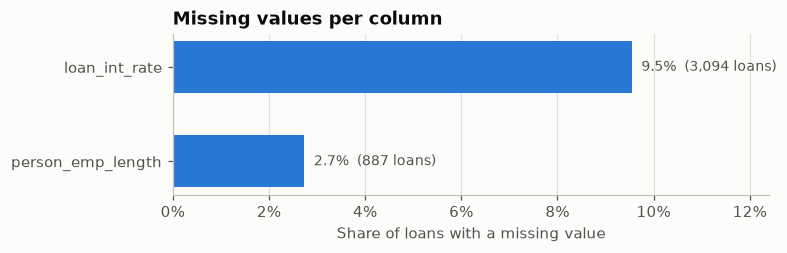

person_emp_length    default rate when missing 31.7% | when present 21.6%
loan_int_rate        default rate when missing 20.7% | when present 22.0%


In [4]:
miss = df.isna().mean()
miss = miss[miss > 0].sort_values()
fig, ax = plt.subplots(figsize=(7, 1.9))
ax.barh(miss.index, miss.values, color=BLUE, height=0.55)
ax.xaxis.set_major_formatter(pct); ax.grid(axis="y", visible=False)
ax.set_xlim(0, miss.max() * 1.3)
for i, v in enumerate(miss.values):
    ax.text(v + 0.002, i, f"{v:.1%}  ({df[miss.index[i]].isna().sum():,} loans)", va="center", color=INK2, fontsize=9)
ax.set_xlabel("Share of loans with a missing value")
ax.set_title("Missing values per column")
save(fig, "01_missing_values")

for col in miss.index:
    m = df[col].isna()
    print(f"{col:20s} default rate when missing {y[m].mean():.1%} | when present {y[~m].mean():.1%}")

**Insight:** `loan_int_rate` is missing for **9.5%** of loans (3,094) and `person_emp_length` for **2.7%** (887). A missing
interest rate says little about risk (20.7% default vs 22.0%), but a missing employment length does:
those borrowers default **31.7%** of the time vs 21.6% - so "was missing" flags are worth keeping.

## 3. Target: how many loans default?

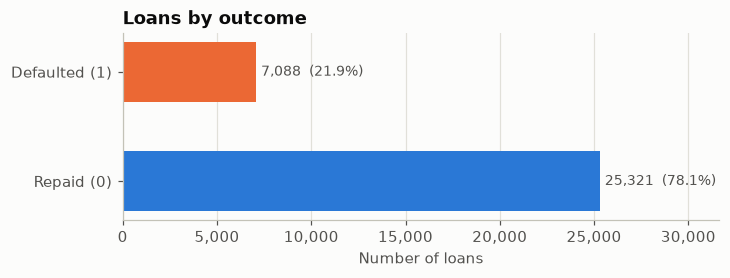

In [5]:
counts = y.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 2.2))
ax.barh(["Repaid (0)", "Defaulted (1)"], counts.values, color=[BLUE, ORANGE], height=0.55)
ax.grid(axis="y", visible=False)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
for i, v in enumerate(counts.values):
    ax.text(v + 250, i, f"{v:,}  ({v / len(y):.1%})", va="center", color=INK2, fontsize=9)
ax.set_xlim(0, counts.max() * 1.25)
ax.set_xlabel("Number of loans")
ax.set_title("Loans by outcome")
save(fig, "02_target_balance")

**Insight:** **21.9%** of loans default (7,088 of 32,409, about 1 in 5). The data is **imbalanced**, so:
- accuracy is misleading (predicting "repaid" for everyone is already 78% accurate) - we use **ROC-AUC**, PR-AUC and recall;
- models get class weights (`class_weight` / `scale_pos_weight`) or SMOTE;
- train / validation / test splits are stratified so each keeps the 21.9% rate.

## 4. Default rate by loan and borrower categories

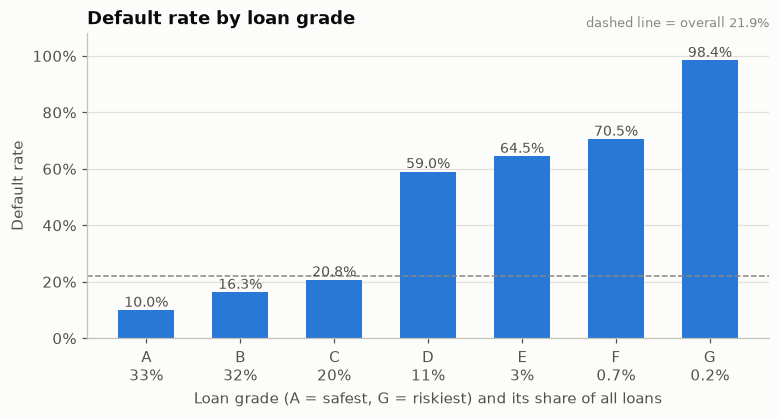

In [6]:
by_grade = y.groupby(df.loan_grade).mean()
share = df.loan_grade.value_counts(normalize=True).reindex(by_grade.index)
fig, ax = plt.subplots(figsize=(8, 3.6))
default_rate_bars(ax, by_grade, OVERALL, labels=[f"{g}\n{s:.0%}" if s >= 0.01 else f"{g}\n{s:.1%}" for g, s in share.items()])
ax.set_ylim(0, 1.08)
ax.set_xlabel("Loan grade (A = safest, G = riskiest) and its share of all loans")
ax.set_ylabel("Default rate")
ax.set_title("Default rate by loan grade")
save(fig, "03_default_by_loan_grade")

**Insight:** risk climbs with grade - **10.0% for grade A to 98.4% for grade G** - with a big jump between
**C (20.8%) and D (59.0%)**. Grades A and B are 65% of all loans. Grade is the strongest single feature, used
as the number `loan_grade_num` (A=1 ... G=7). Grades F and G have only 241 and 64 loans, so their rates are less certain.

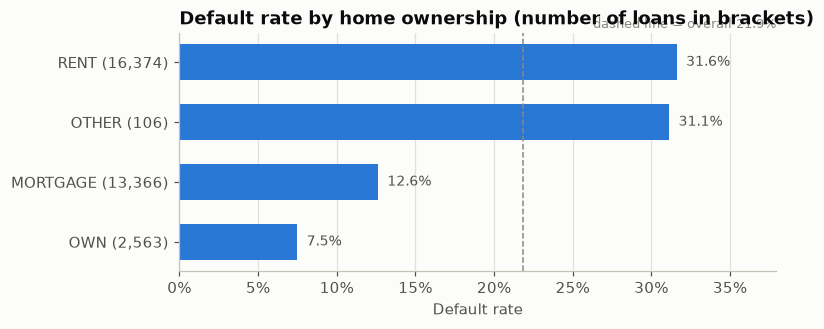

In [7]:
by_home = y.groupby(df.person_home_ownership).mean().sort_values()
counts_home = df.person_home_ownership.value_counts()
fig, ax = plt.subplots(figsize=(7, 2.8))
default_rate_bars(ax, by_home, OVERALL, horizontal=True,
                  labels=[f"{h} ({counts_home[h]:,})" for h in by_home.index])
ax.set_xlim(0, by_home.max() * 1.2)
ax.set_xlabel("Default rate")
ax.set_title("Default rate by home ownership (number of loans in brackets)")
save(fig, "04_default_by_home_ownership")

**Insight:** renters default **31.6%** of the time vs **12.6%** for mortgage holders and **7.5%** for owners -
renters are 4x riskier than owners. RENT and MORTGAGE together are 92% of loans; OTHER has only 106 loans.

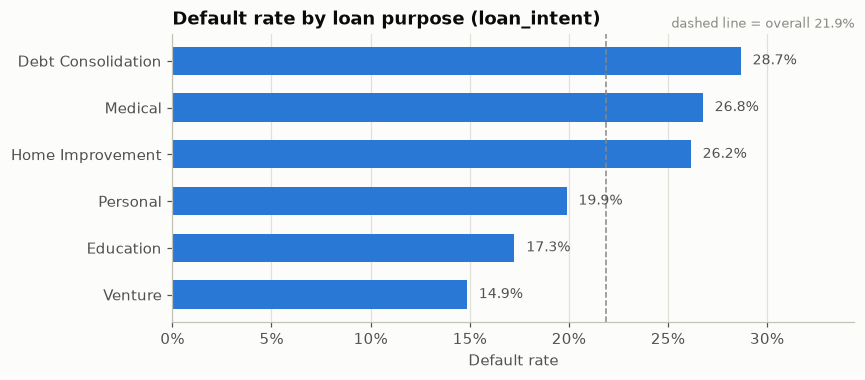

In [8]:
by_intent = y.groupby(df.loan_intent).mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 3.4))
default_rate_bars(ax, by_intent, OVERALL, horizontal=True,
                  labels=[i.replace("DEBTCONSOLIDATION", "DEBT CONSOLIDATION").replace("HOMEIMPROVEMENT", "HOME IMPROVEMENT").title()
                          for i in by_intent.index])
ax.set_xlim(0, by_intent.max() * 1.2)
ax.set_xlabel("Default rate")
ax.set_title("Default rate by loan purpose (loan_intent)")
save(fig, "05_default_by_loan_intent")

**Insight:** **debt consolidation (28.7%)**, **medical (26.8%)** and **home improvement (26.2%)** loans are the
riskiest; **venture (14.9%)** and **education (17.3%)** the safest. The six purposes are fairly evenly used
(11-20% of loans each). In the drift simulation (Step 9) a shift towards debt consolidation and medical loans
therefore means a riskier portfolio.

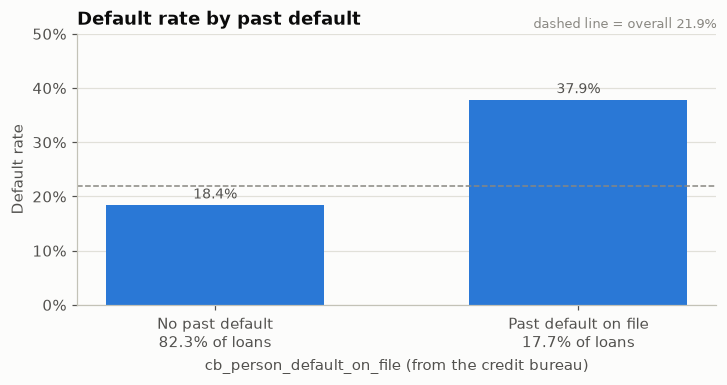

loan_grade                     A      B      C      D      E      F      G
cb_person_default_on_file                                                 
0                          0.401  0.389  0.120  0.065  0.019  0.005  0.001
1                          0.000  0.000  0.566  0.327  0.081  0.020  0.006


In [9]:
by_past = y.groupby(df.cb_person_default_on_file).mean()
share_past = df.cb_person_default_on_file.value_counts(normalize=True)
fig, ax = plt.subplots(figsize=(7.5, 3.2))
default_rate_bars(ax, by_past, OVERALL,
                  labels=[f"No past default\n{share_past[0]:.1%} of loans", f"Past default on file\n{share_past[1]:.1%} of loans"])
ax.set_xlabel("cb_person_default_on_file (from the credit bureau)")
ax.set_ylim(0, 0.5)
ax.set_ylabel("Default rate")
ax.set_title("Default rate by past default")
save(fig, "06_default_by_past_default")
print(pd.crosstab(df.cb_person_default_on_file, df.loan_grade, normalize="index").round(3))

**Insight:** borrowers with a **past default on file** default **37.9%** of the time vs **18.4%** without
(2.1x). They are 17.7% of loans. None of them received grade A or B (see table), so the lender already used
this flag when setting the grade - the two features overlap (correlation 0.54).

## 5. Default rate across numeric features
Each numeric feature is split into five equal-sized groups (quintiles, lowest to highest) and the default rate
is shown per group. A rising pattern means "more of this feature, more risk". The labels show the value range of each group.

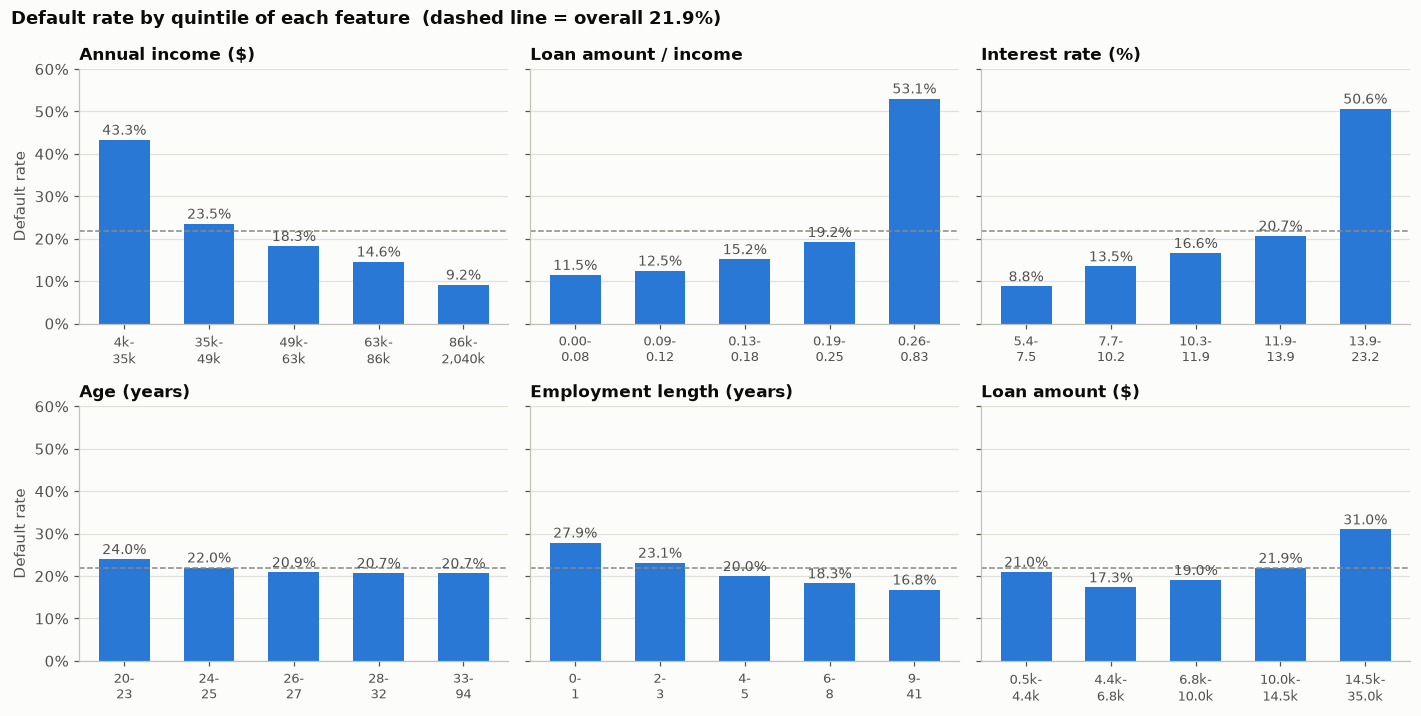

,Q1 lowest,Q2,Q3,Q4,Q5 highest
person_income,0.433,0.235,0.183,0.146,0.092
loan_percent_income,0.115,0.125,0.152,0.192,0.531
loan_int_rate,0.088,0.135,0.166,0.207,0.506
person_age,0.240,0.220,0.209,0.207,0.207
person_emp_length,0.279,0.231,0.200,0.183,0.168
loan_amnt,0.210,0.173,0.190,0.219,0.310


In [10]:
features = {
    "person_income": ("Annual income ($)", lambda v: f"{v / 1000:,.0f}k"),
    "loan_percent_income": ("Loan amount / income", lambda v: f"{v:.2f}"),
    "loan_int_rate": ("Interest rate (%)", lambda v: f"{v:.1f}"),
    "person_age": ("Age (years)", lambda v: f"{v:.0f}"),
    "person_emp_length": ("Employment length (years)", lambda v: f"{v:.0f}"),
    "loan_amnt": ("Loan amount ($)", lambda v: f"{v / 1000:,.1f}k"),
}
fig, axes = plt.subplots(2, 3, figsize=(13, 6.6), sharey=True)
quintile_rates = {}
for ax, (col, (title, fmt)) in zip(axes.flat, features.items()):
    bins = pd.qcut(df[col], 5, duplicates="drop")
    rates = y.groupby(bins, observed=True).mean()
    ranges = df.groupby(bins, observed=True)[col].agg(["min", "max"])
    labels = [f"{fmt(lo)}-\n{fmt(hi)}" for lo, hi in ranges.to_numpy()]
    default_rate_bars(ax, rates, OVERALL, labels=labels, note=False)
    ax.tick_params(axis="x", labelsize=8.5)
    ax.set_title(title, fontsize=11)
    quintile_rates[col] = rates.round(3).tolist()
axes[0, 0].set_ylim(0, 0.6)
for ax in axes[:, 0]:
    ax.set_ylabel("Default rate")
fig.suptitle(f"Default rate by quintile of each feature  (dashed line = overall {OVERALL:.1%})",
             x=0.01, ha="left", fontweight="bold", color=INK)
fig.tight_layout()
save(fig, "07_default_by_numeric_quintiles")
pd.DataFrame(quintile_rates, index=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"]).T

**Insights:**
- **Income:** the poorest fifth defaults **43.3%** vs **9.2%** for the richest fifth - the strongest numeric pattern.
- **Loan / income** and **interest rate**: flat for the first four fifths, then a jump in the top fifth
  (**53.1%** and **50.6%**). The risk is concentrated in the most stretched / most expensive loans.
- **Employment length:** longer employment, lower risk (**27.9%** for 0-1 years vs **16.8%** for 9+ years).
- **Loan amount:** only the largest fifth stands out (**31.0%**).
- **Age** barely matters (24.0% for the youngest fifth vs 20.7% for the oldest).

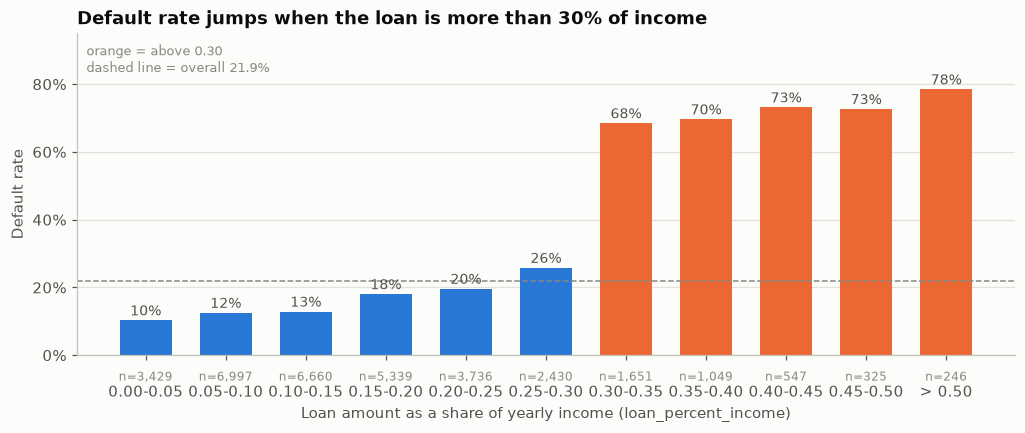

<= 0.30: 15.4% default (88.2% of loans)
>  0.30: 70.4% default (11.8% of loans)


In [11]:
edges = [0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 1.0]
bands = pd.cut(df.loan_percent_income, edges, include_lowest=True)
lpi = y.groupby(bands, observed=True).agg(["mean", "size"])
labels = [f"{a:.2f}-{b:.2f}" if b < 1 else f"> {a:.2f}" for a, b in zip(edges[:-1], edges[1:])]
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.bar(labels, lpi["mean"], color=[BLUE if b <= 0.30 else ORANGE for b in edges[1:]], width=0.65)
ax.axhline(OVERALL, color=MUTED, ls="--", lw=1)
for i, (v, n) in enumerate(lpi.to_numpy()):
    ax.text(i, v + 0.015, f"{v:.0%}", ha="center", color=INK2, fontsize=9)
    ax.text(i, -0.075, f"n={n:,.0f}", ha="center", color=MUTED, fontsize=8)
ax.set_ylim(0, 0.95); ax.yaxis.set_major_formatter(pct); ax.grid(axis="x", visible=False)
ax.tick_params(axis="x", pad=16)
ax.set_xlabel("Loan amount as a share of yearly income (loan_percent_income)")
ax.set_ylabel("Default rate")
ax.text(0.01, 0.97, f"orange = above 0.30\ndashed line = overall {OVERALL:.1%}", transform=ax.transAxes,
        ha="left", va="top", color=MUTED, fontsize=8.5)
ax.set_title("Default rate jumps when the loan is more than 30% of income")
save(fig, "08_default_by_loan_percent_income")
below, above = df.loan_percent_income <= 0.30, df.loan_percent_income > 0.30
print(f"<= 0.30: {y[below].mean():.1%} default ({below.mean():.1%} of loans)")
print(f">  0.30: {y[above].mean():.1%} default ({above.mean():.1%} of loans)")

**Insight:** while the loan is at most 30% of yearly income, the default rate rises slowly from 10% to 26%
(**15.4%** for that whole group, 88.2% of loans). Above 30% it jumps to **68-78%** (**70.4%** for the group, 11.8% of loans). Such a sharp step is easy for a tree model to learn but hard for a straight-line
(logistic) model - one reason gradient boosting scores higher than logistic regression on this data.

## 6. Distributions: repaid vs defaulted
The shape of each feature for the two groups. The more the two curves are separated, the more useful the feature.

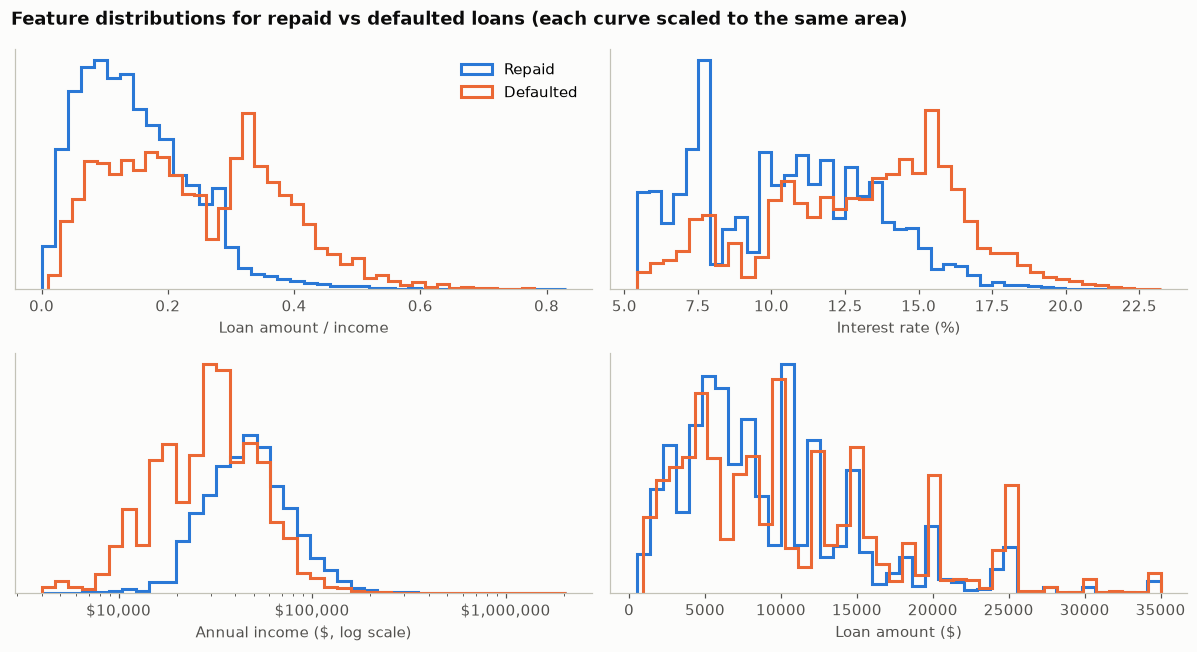

,loan_percent_income,loan_int_rate,person_income,loan_amnt
loan_status,,,,
repaid (median),0.13,10.59,60000.0,8000.0
defaulted (median),0.24,13.49,41655.0,9600.0


In [12]:
dist = {"loan_percent_income": ("Loan amount / income", False), "loan_int_rate": ("Interest rate (%)", False),
        "person_income": ("Annual income ($, log scale)", True), "loan_amnt": ("Loan amount ($)", False)}
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, (col, (label, log)) in zip(axes.flat, dist.items()):
    x = df[col].dropna()
    bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 40) if log else 40
    for val, color, name in [(0, BLUE, "Repaid"), (1, ORANGE, "Defaulted")]:
        ax.hist(x[y.loc[x.index] == val], bins=bins, density=True, histtype="step", lw=2, color=color, label=name)
    if log:
        ax.set_xscale("log")
        ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v:,.0f}"))
    ax.set_xlabel(label); ax.set_yticks([]); ax.grid(False)
axes[0, 0].legend(loc="upper right")
fig.suptitle("Feature distributions for repaid vs defaulted loans (each curve scaled to the same area)",
             x=0.01, ha="left", fontweight="bold", color=INK)
fig.tight_layout()
save(fig, "09_distributions_repaid_vs_default")
df.groupby("loan_status")[list(dist)].median().rename(index={0: "repaid (median)", 1: "defaulted (median)"})

**Insight:** defaulted loans take a much **bigger share of income** (median 0.24 vs 0.13), pay **higher interest**
(13.5% vs 10.6%) and come from **lower incomes** ($41,655 vs $60,000). Loan amounts differ less ($9,600 vs $8,000).
The curves overlap, so no single feature separates the classes on its own - the model must combine them.

## 7. Outliers before vs after cleaning
The raw file contains impossible values (ages up to 144, employment up to 123 years). Cleaning removes those rows.

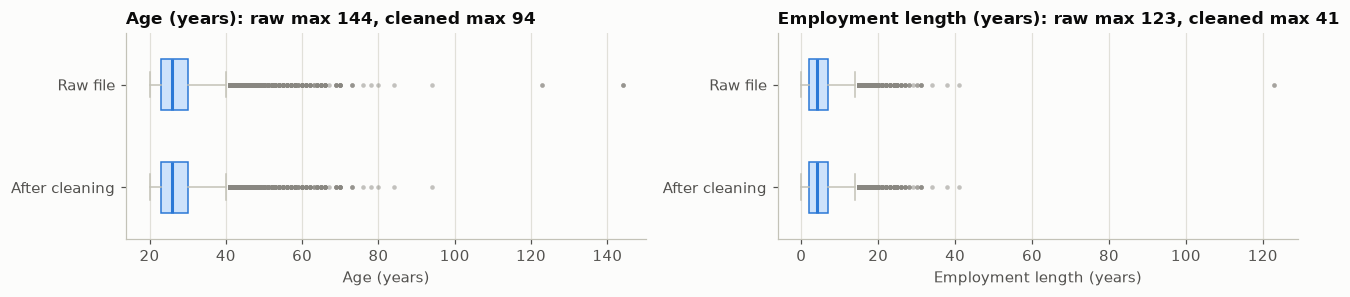

Income: median $55,000, max raw $6,000,000, max cleaned $2,039,784, incomes above $1M kept: 8


In [13]:
cols = {"person_age": "Age (years)", "person_emp_length": "Employment length (years)"}
fig, axes = plt.subplots(1, 2, figsize=(12, 2.8))
box_style = dict(orientation="horizontal", widths=0.5, patch_artist=True,
                 boxprops=dict(facecolor="#cde2fb", edgecolor=BLUE), medianprops=dict(color=BLUE, lw=2),
                 whiskerprops=dict(color=AXIS), capprops=dict(color=AXIS),
                 flierprops=dict(marker="o", markersize=3, markerfacecolor=MUTED, markeredgecolor="none", alpha=0.5))
for ax, (col, label) in zip(axes, cols.items()):
    ax.boxplot([df[col].dropna(), raw[col].dropna()], **box_style)
    ax.set_yticks([1, 2], ["After cleaning", "Raw file"])
    ax.grid(axis="y", visible=False)
    ax.set_xlabel(label)
    ax.set_title(f"{label}: raw max {raw[col].max():.0f}, cleaned max {df[col].max():.0f}", fontsize=11)
fig.tight_layout()
save(fig, "10_outliers_before_after_cleaning")
print(f"Income: median ${df.person_income.median():,.0f}, max raw ${raw.person_income.max():,.0f}, "
      f"max cleaned ${df.person_income.max():,.0f}, incomes above $1M kept: {(df.person_income > 1e6).sum()}")

**Insight:** the raw maximums (**age 144, employment 123 years**) are data entry errors; after removing the 7
impossible rows the maximums are **age 94** and **41 years** of employment. The removed rows also held the
largest income ($6,000,000). Income stays right-skewed (median $55,000, 8 incomes above $1M, max $2,039,784) -
these are kept because they are possible; Logistic Regression gets a log transform, trees do not need one.

## 8. Correlation between numeric features

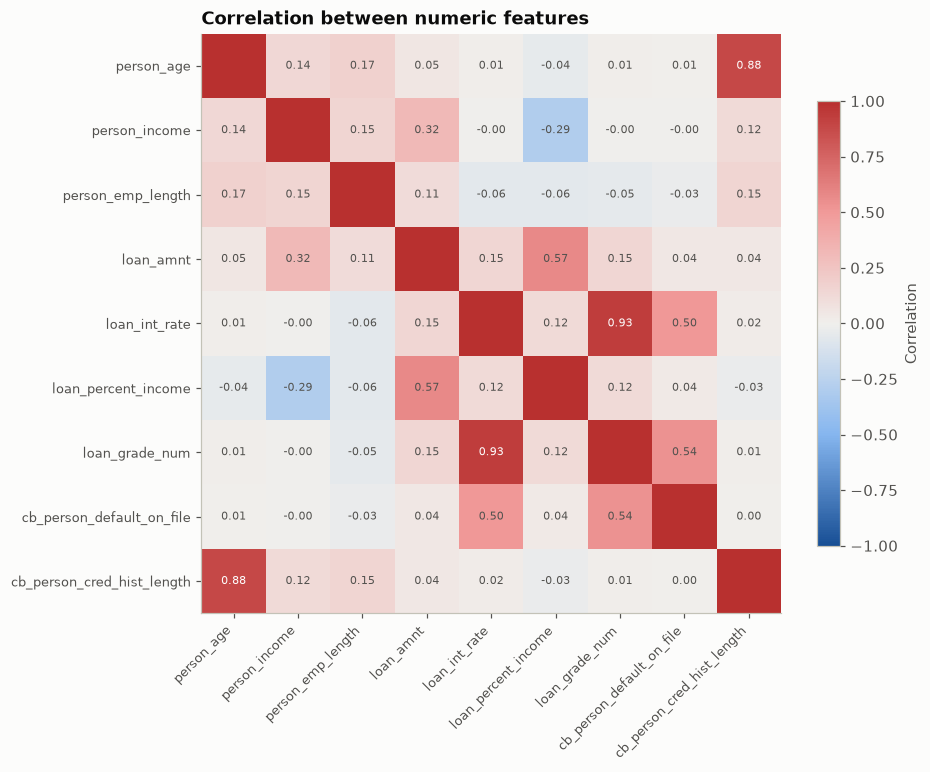

,,correlation
loan_int_rate,loan_grade_num,0.93
person_age,cb_person_cred_hist_length,0.88
loan_amnt,loan_percent_income,0.57
loan_grade_num,cb_person_default_on_file,0.54
loan_int_rate,cb_person_default_on_file,0.50


In [14]:
corr = df[NUMERIC_FEATURES].corr()
cmap = LinearSegmentedColormap.from_list("div", ["#184f95", "#86b6ef", "#f0efec", "#f19a99", "#b8302f"])
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right", fontsize=8.5)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=8.5)
ax.grid(False)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        if i != j:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                    color="white" if abs(v) >= 0.6 else INK2)
fig.colorbar(im, ax=ax, shrink=0.75, label="Correlation")
ax.set_title("Correlation between numeric features")
save(fig, "11_correlation_heatmap")

pairs = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
pairs[pairs.abs() >= 0.5].sort_values(ascending=False).round(2).to_frame("correlation")

**Insight:** two pairs carry almost the same information:
- `loan_int_rate` and `loan_grade_num` (**0.93**) - the lender sets the rate from the grade;
- `person_age` and `cb_person_cred_hist_length` (**0.88**) - older people have longer credit histories.

`loan_amnt` ~ `loan_percent_income` (0.57) and grade ~ past default (0.54) are related but not duplicates.
Tree models cope with correlated inputs, but for **Logistic Regression** we drop `loan_int_rate` and
`cb_person_cred_hist_length` (`LINEAR_DROP_FEATURES` in `src/features.py`) so the coefficients stay stable.

## 9. Which single features separate default best? (leakage check)
ROC-AUC of each feature on its own (0.5 = coin toss, 1.0 = perfect). For a categorical feature the score is
the default rate of its category. Direction and category rates are learned on the **training** split and the AUC is
measured on the **validation** split (same code as `src/leakage_check.py`). A single feature above **0.90**
would suggest the column contains the answer (leakage).

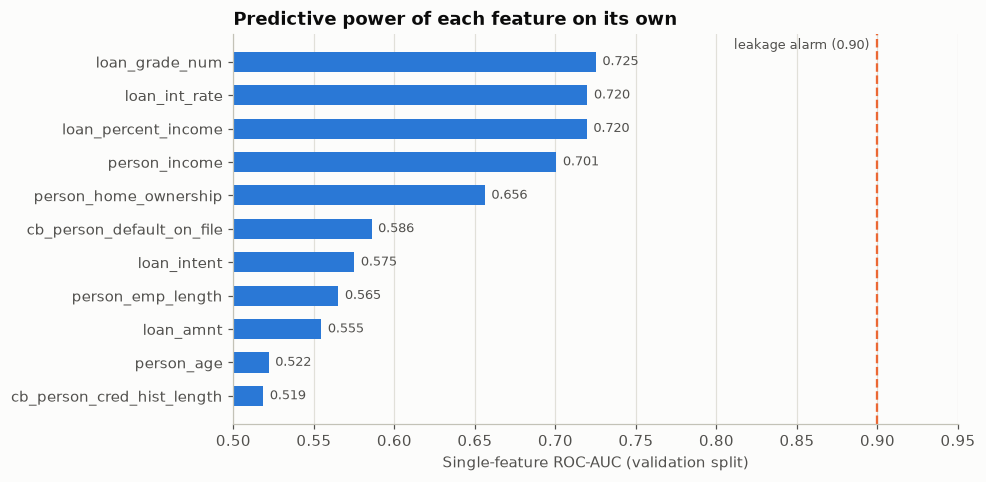

In [15]:
d = get_splits()
auc = single_feature_auc(d["X_train"], d["y_train"], d["X_val"], d["y_val"]).sort_values()
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.barh(auc.index, auc.values - 0.5, left=0.5, color=BLUE, height=0.6)
ax.axvline(0.5, color=MUTED, lw=1)
ax.axvline(0.90, color=ORANGE, ls="--", lw=1.5)
ax.text(0.895, len(auc) - 0.5, "leakage alarm (0.90)", ha="right", va="center", color=INK2, fontsize=8.5)
ax.set_xlim(0.5, 0.95); ax.grid(axis="y", visible=False)
for i, v in enumerate(auc.values):
    ax.text(v + 0.004, i, f"{v:.3f}", va="center", color=INK2, fontsize=8.5)
ax.set_xlabel("Single-feature ROC-AUC (validation split)")
ax.set_title("Predictive power of each feature on its own")
save(fig, "12_single_feature_auc")

**Insight:** the best single features are **loan grade (0.725)**, **interest rate (0.720)**,
**loan / income (0.720)** and **income (0.701)**, then home ownership (0.656). Age (0.522) and credit history
length (0.519) are almost useless alone. **No feature comes close to the 0.90 alarm**, so there is no sign of a
leaking column. Quick untuned models on the same split reach **0.878 (Logistic Regression)** and
**0.936 (Gradient Boosting)** - high, but explained by the strong, step-like patterns above (grade C->D, loan/income
above 0.30, renters vs owners) combining together. Details: `reports/leakage_check.md`.

## 10. Key findings (summary for the report)

| # | Finding | Chart | What we do with it |
|---|---|---|---|
| 1 | 165 duplicates and 7 impossible rows (age 144, 123 years employed) removed; 32,409 loans left | 10 | Cleaning in `src/clean_data.py`, with checks that fail loudly |
| 2 | 21.9% of loans default (imbalanced) | 02 | ROC-AUC / PR-AUC, class weights or SMOTE, stratified splits |
| 3 | Grade A 10.0% vs grade G 98.4%; big jump C 20.8% -> D 59.0% | 03 | Strongest single feature; used once, as `loan_grade_num` |
| 4 | Loan > 30% of income: 70.4% default vs 15.4% below | 08 | Keep `loan_percent_income`; tree models capture the step |
| 5 | Renters 31.6% vs owners 7.5% | 04 | Keep home ownership (one-hot) |
| 6 | Poorest fifth 43.3% vs richest 9.2% | 07 | Keep income; log transform for Logistic Regression |
| 7 | Past default on file: 37.9% vs 18.4% | 06 | Keep the flag (1/0) |
| 8 | Debt consolidation 28.7% vs venture 14.9% | 05 | Keep loan intent; use it in the drift simulation |
| 9 | Interest rate 9.5% missing, employment length 2.7% (31.7% default when missing) | 01 | Median imputation + missing flags inside the pipeline |
| 10 | Grade ~ interest rate 0.93, age ~ credit history 0.88 | 11 | Drop one of each pair for Logistic Regression |
| 11 | Best single feature AUC 0.725 - far below the 0.90 alarm | 12 | No leakage; realistic model AUC ~0.93-0.95 |
| 12 | No date column | - | Drift is simulated from the test split (Step 9) |